# Dogs vs Cats
https://www.kaggle.com/c/dogs-vs-cats-redux-kernels-edition

In [3]:
import cv2
import numpy as np
import pandas as pd
import io
import os
import glob
from random import shuffle
import zipfile
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import vgg16

## Загрузка основного архива данных

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path_data_zip = '/content/drive/MyDrive/DFD_Учёба/Домашнее Задание/14. Компьютерное зрение/ДЗ_2_Обучение сверточной сети на практике/DATA/DATA_dogs-vs-cats.zip'

In [6]:
with zipfile.ZipFile(file=path_data_zip) as zip_data:
  list_file = [list_.filename for list_ in  zip_data.filelist]
  print(f'Содержимое основного архива:\n{list_file}')
  zip_data.extract('sample_submission.csv')


  for filename in list_file:
    if filename.endswith('.zip'):               #endswith()- это метод строки в Python
      nested_zip_data = zip_data.read(filename) # Читаем вложенный архив в память!!!

      with zipfile.ZipFile(io.BytesIO(nested_zip_data)) as nested_zip:
          nested_zip.extractall()

Содержимое основного архива:
['sample_submission.csv', 'test.zip', 'train.zip']


In [7]:
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission.head(3)

,id,label
0,1,0.5
1,2,0.5
2,3,0.5


## Загрузка и подготовка данных

In [8]:
#  Поиска всех файлов с расширением .jpg внутри каталога train и test. Результат сохраняется в переменную train_files.
train_list_files = glob.glob('train/*.jpg')
test_list_files = glob.glob('test/*.jpg')

In [9]:
print(train_list_files[:5])
len(train_list_files)

['train/dog.6652.jpg', 'train/dog.10321.jpg', 'train/dog.5503.jpg', 'train/cat.3867.jpg', 'train/dog.10056.jpg']


25000

In [10]:
# загружаем входное изображение и предобрабатываем

IMG_SIZE = (224, 224)  # размер входного изображения сети

def load_image(path, target_size=IMG_SIZE):
    img = cv2.imread(path)[...,::-1]
    img = cv2.resize(img, target_size)
    return vgg16.preprocess_input(img) # предобработка для MobileNetV2

In [11]:
# функция-генератор загрузки обучающих данных с диска
def fit_generator(files, batch_size=32):
    batch_size = min(batch_size, len(files))
    while True:
        shuffle(files)
        for k in range(len(files) // batch_size):
            i = k * batch_size
            j = i + batch_size
            if j > len(files):
                j = - j % len(files)
            x = np.array([load_image(path) for path in files[i:j]])
            y = np.array([1. if os.path.basename(path).startswith('dog') else 0.
                          for path in files[i:j]])
            yield (x, y)

In [27]:
# функция-генератор загрузки тестовых изображений с диска
def predict_generator(files):
    while True:
        for path in files:
            yield np.array([load_image(path)]),

## Визуализируем примеры для обучения

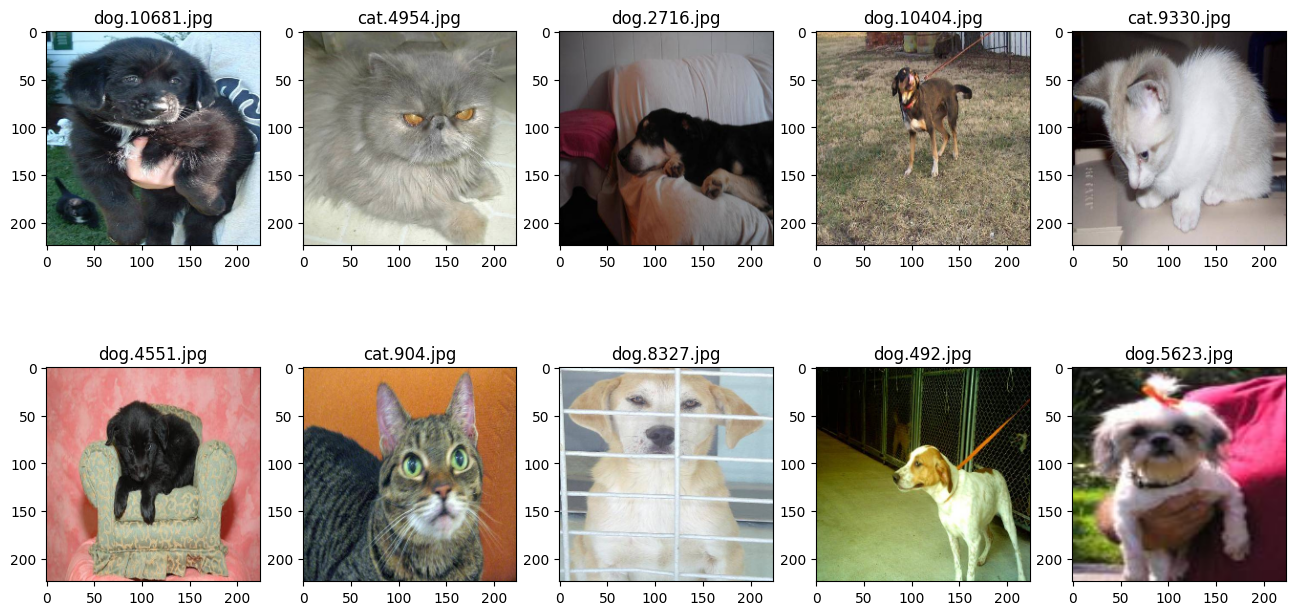

In [13]:
fig = plt.figure(figsize=(16, 8))
for i, path in enumerate(train_list_files[25:35], 1):
    subplot = fig.add_subplot(2, 5, i)
    subplot.set_title('%s' % path.split('/')[-1])
    img = cv2.imread(path)[...,::-1]
    img = cv2.resize(img, IMG_SIZE)
    plt.imshow(img)

## Загружаем предобученную модель

In [14]:
include_top=False # с целью добавления своих собственных слоев, которые будут принимать решения конкретно для своей задачи

base_model = vgg16.VGG16(weights='imagenet',
                         include_top=False,
                         input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [15]:
# Архитектура модели
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## Transfer learning или "fine-tuning" (передаточное обучение)/Добавляем полносвязный слой

In [16]:
# фиксируем все веса предобученной модели
for layer in base_model.layers:
    layer.trainable = False
"""замораживаем все слои предобученной модели, устанавливая параметр trainable = False.
1. Все знания, которые модель получила ранее (например, на ImageNet), сохраняются
2. При обучении веса этих слоев меняться не будут
3. Экономит вычислительные ресурсы и предотвращает переобучение"""

# Создание новой архитектуры (формируем новые, свои слои):

x = base_model.layers[-2].output         # Выполняю ответление из базовой обученной модели из предпоследнего слоя.
x = tf.keras.layers.Flatten()(x)         # Преобразование многомерных данных (например, 3D тензор) в плоский вектор, чтобы передать его в полносвязный слой.
x = tf.keras.layers.Dense(1,             # Один выход (бинарная классификация)
                          activation='sigmoid',  # функция активации
                          kernel_regularizer=tf.keras.regularizers.l1(1e-4))(x)

# Окончательное формирование "своей" модели
my_model = tf.keras.Model(inputs=base_model.input, outputs=x, name='dogs_vs_cats')

In [17]:
my_model.summary()

Model: "dogs_vs_cats"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       100,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,815,041 (56.51 MB)

 Trainable params: 100,353 (392.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Компилируем модель

In [18]:
my_model.compile(optimizer='adam',
              loss='binary_crossentropy',  # функция потерь binary_crossentropy (log loss), для многоклассовой categorical_crossentropy
              metrics=['accuracy'])

## Загрузка и подготовка данных перед обучением. Препроцессинг

In [19]:
val_samples = 5  # число изображений в валидационной выборке

shuffle(train_list_files)  # перемешиваем обучающую выборку
validation_data = next(fit_generator(train_list_files[:val_samples]))
train_data = fit_generator(train_list_files[val_samples:])  # данные читаем функцией-генератором



In [20]:
len(validation_data[0][0][0])

224

In [21]:
# запускаем процесс обучения
my_model.fit(train_data,
          steps_per_epoch=100,  # число вызовов генератора за эпоху
          epochs=10,  # число эпох обучения
          validation_data=validation_data)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 193ms/step - accuracy: 0.8968 - loss: 2.9264 - val_accuracy: 1.0000 - val_loss: 0.0667
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.9697 - loss: 1.5708 - val_accuracy: 1.0000 - val_loss: 0.0874
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 162ms/step - accuracy: 0.9687 - loss: 1.2477 - val_accuracy: 1.0000 - val_loss: 0.1062
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.9642 - loss: 3.4877 - val_accuracy: 1.0000 - val_loss: 0.1233
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.9781 - loss: 1.7686 - val_accuracy: 1.0000 - val_loss: 0.1361
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 176ms/step - accuracy: 0.9706 - loss: 2.3596 - val_accuracy: 1.0000 - val_loss: 0.1490
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 175ms/step - accuracy: 0.9776 - loss: 2.0039 - val_accuracy: 1.0000 - val_loss: 0.1586
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 171ms/step - accuracy: 0.9749 - loss: 2

In [22]:
my_model.save('cats-dogs-vgg16.hdf5')

## Предсказание на тестовой выборке

In [28]:
test_pred = my_model.predict(
    predict_generator(test_list_files), steps=len(test_list_files))

12500/12500 ━━━━━━━━━━━━━━━━━━━━ 121s 9ms/step


/tmp/ipython-input-2069404945.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  subplot.set_title('%.2f %s' % (score, os.path.basename(path)))


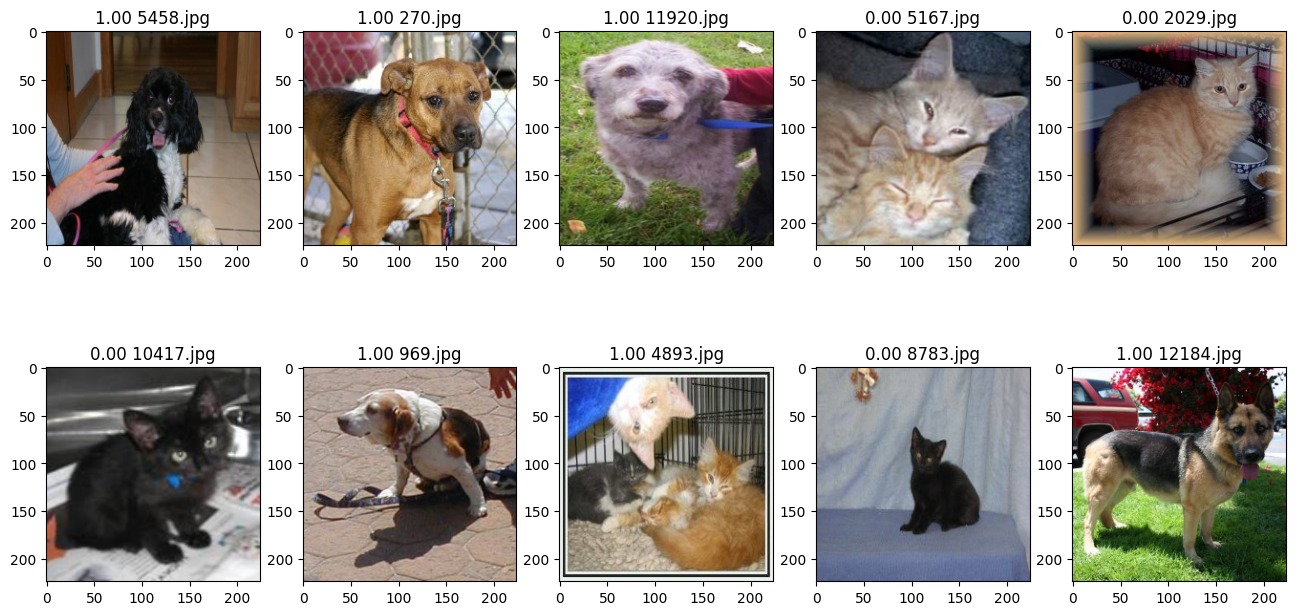

In [29]:
fig = plt.figure(figsize=(16, 8))
for i, (path, score) in enumerate(zip(test_list_files[25:35], test_pred[25:35]), 1):
    subplot = fig.add_subplot(2, 5, i)
    subplot.set_title('%.2f %s' % (score, os.path.basename(path)))
    img = cv2.imread(path)[...,::-1]
    img = cv2.resize(img, IMG_SIZE)
    subplot.imshow(img)

## Отправка результата

In [31]:
import re

with open('submit.csv', 'w') as dst:
    dst.write('id,label\n')
    for path, score in zip(test_list_files, test_pred):
        dst.write('%s,%f\n' % (re.search('(\d+).jpg$', path).group(1), score))

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1674594790.py:6: SyntaxWarning: invalid escape sequence '\d'
  dst.write('%s,%f\n' % (re.search('(\d+).jpg$', path).group(1), score))
/tmp/ipython-input-1674594790.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dst.write('%s,%f\n' % (re.search('(\d+).jpg$', path).group(1), score))


In [32]:
df_submit = pd.read_csv('submit.csv')
df_submit.head()

,id,label
0,9707,1.0
1,7940,0.0
2,537,0.0
3,1944,0.0
4,4782,1.0


**Оценка: 0,95791**